
-----

# 🎯 ***`ANOVA Case Study`*** 🤺

----

### **Import Libraries**

In [9]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### **Use `ANOVA` on titanic data from seaborn library**

In [2]:

# load tips data
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### **Impute missing Values**

In [3]:

# impute missing values in 'age' and 'fare' column
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

print("Missind values in 'age' and 'fare' imputed successfully.")

Missind values in 'age' and 'fare' imputed successfully.


### **Apply one-way ANOVA**

`Hypothesis` :
- There is a difference between ages of First, Second and third class passangers.
  - **H₀ (Null Hypothesis)**: There is no Age difference. (no difference).  
  - **H₁ (Alternative Hypothesis)**: There is Age Difference (significant difference).

In [4]:

# stats models
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVa test for age and class
model = ols("age ~ pclass", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# print the results based on p value and if else conditions
if anova_table['PR(>F)'][0] < 0.05:
    print(f"\nReject null hypothesis, because p vaule: {anova_table['PR(>F)'][0]} , there is a significant difference between ages of passengers in different classes.")
else:
    print(f"\nFail to reject null hypothesis,because p vaule: {anova_table['PR(>F)'][0]}, there is not any differences between ages of passengers in different classes.")


                 sum_sq     df           F        PR(>F)
pclass     17429.695048    1.0  116.122704  1.558883e-25
Residual  133436.428421  889.0         NaN           NaN

Reject null hypothesis, because p vaule: 1.5588829926632724e-25 , there is a significant difference between ages of passengers in different classes.


### **`PostHoc Test`**

In [5]:

# Tukey HSD pairwise comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['age'], groups=df['pclass'], alpha=0.05)
tukey.summary()


group1,group2,meandiff,p-adj,lower,upper,reject
1,2,-7.0467,0.0,-9.9299,-4.1636,True
1,3,-10.8795,0.0,-13.226,-8.533,True
2,3,-3.8328,0.0009,-6.3169,-1.3486,True


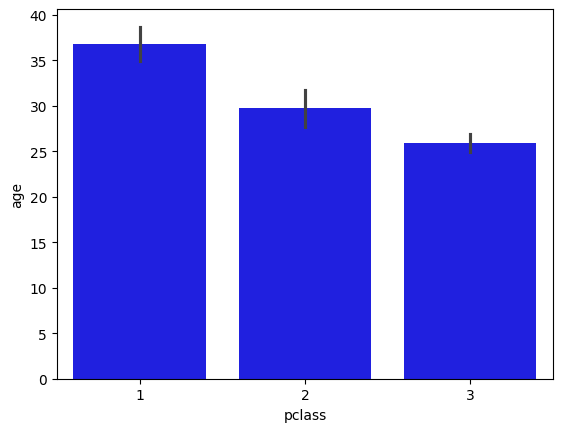

In [ ]:

# plot barplot to visualize ages according to class
sns.barplot(x="pclass",y="age",data=df,color="b")
plt.show()


## **`Two-way ANOVA`**

In [11]:

# stats models
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVa test for age and class
# model = ols("age ~ pclass + who + pclass:who", data=df).fit()
# or this
model = ols("age ~ sex * who", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                sum_sq     df             F        PR(>F)
sex                NaN    1.0           NaN           NaN
who       1.294561e-10    2.0  5.611466e-13  9.999994e-01
sex:who   5.233208e+04    2.0  2.268412e+02  8.119221e-46
Residual  1.023151e+05  887.0           NaN           NaN


In [12]:

# Tukey HSD pairwise comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df['age'], df['sex'] + df['who'] , alpha=0.05)
tukey.summary()


group1,group2,meandiff,p-adj,lower,upper,reject
femalechild,femalewoman,24.0084,0.0,19.4706,28.5462,True
femalechild,malechild,-1.7426,0.8815,-7.8152,4.3301,False
femalechild,maleman,24.7693,0.0,20.3881,29.1505,True
femalewoman,malechild,-25.751,0.0,-30.4333,-21.0686,True
femalewoman,maleman,0.7609,0.7773,-1.299,2.8207,False
malechild,maleman,26.5118,0.0,21.9811,31.0426,True


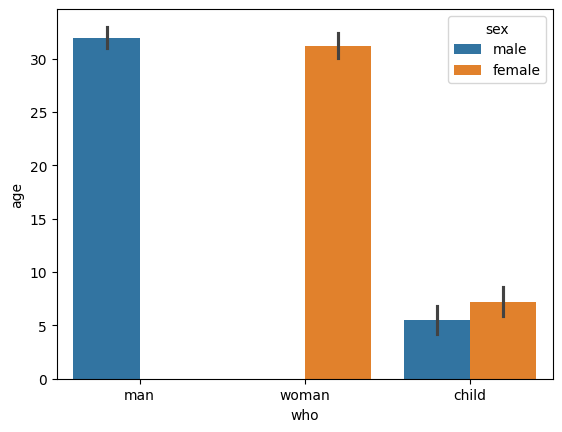

In [13]:

sns.barplot(df, x= 'who', y = 'age', hue='sex')
plt.show()

---